RMSE: 207.81


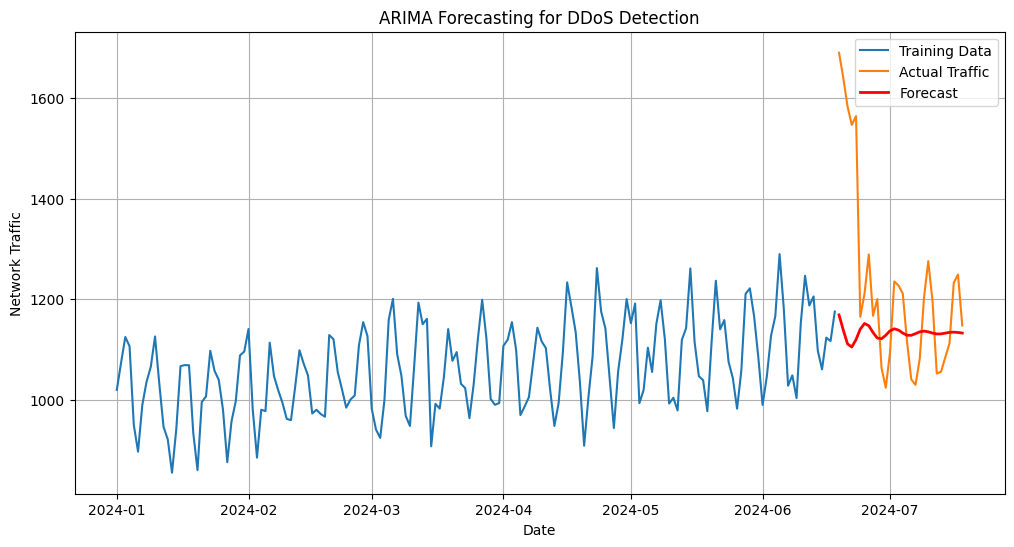

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# -------------------------------
# Generate Sample Network Traffic
# -------------------------------
np.random.seed(42)

dates = pd.date_range(start="2024-01-01", periods=200, freq="D")

traffic = (
    1000
    + np.linspace(0, 150, 200)
    + 100 * np.sin(np.arange(200) * 2 * np.pi / 7)
    + np.random.normal(0, 40, 200)
)

# Simulated DDoS Attack
traffic[170:175] += 500

# Create DataFrame
df = pd.DataFrame({
    "Timestamp": dates,
    "Traffic": traffic
})

# Set Timestamp as Index
df.set_index("Timestamp", inplace=True)

# Set Frequency Explicitly
df = df.asfreq("D")

# -------------------------------
# Train-Test Split
# -------------------------------
train = df.iloc[:170]
test = df.iloc[170:]

# -------------------------------
# Build ARIMA Model
# -------------------------------
model = ARIMA(
    train["Traffic"],
    order=(2, 1, 2),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit()

# -------------------------------
# Forecast
# -------------------------------
forecast = model_fit.forecast(steps=len(test))

# -------------------------------
# Calculate RMSE
# -------------------------------
rmse = np.sqrt(mean_squared_error(test["Traffic"], forecast))
print(f"RMSE: {rmse:.2f}")

# -------------------------------
# Plot Results
# -------------------------------
plt.figure(figsize=(12, 6))

plt.plot(train.index, train["Traffic"], label="Training Data")
plt.plot(test.index, test["Traffic"], label="Actual Traffic")
plt.plot(test.index, forecast, label="Forecast", color="red", linewidth=2)

plt.title("ARIMA Forecasting for DDoS Detection")
plt.xlabel("Date")
plt.ylabel("Network Traffic")
plt.legend()
plt.grid(True)

plt.show()